In [1]:
import os
# os.chdir("/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/optimize-gaussian/src")
import json
from pathlib import Path
from glob import glob
import numpy as np
import pandas as pd


def collect_metric(result_dir, scenes):
    scene_results = {}
    try: 
        for scene in scenes:
            stats_path = os.path.join(result_dir, scene, "stats")
            scene_results[scene] = {"val": {}, "train": {}}
            stats = glob(os.path.join(stats_path, "val_step*.json"))
            if stats is None or len(stats) == 0:
                print(result_dir + " " + scene + " val empty")
                raise RuntimeError(f"No stat files found in {stats_path}.")
            for stat in stats:
                step = os.path.basename(stat).split("_")[1].replace("step", "").replace(".json", "")
                if not os.path.exists(stat):
                    print(result_dir + " " + scene + " val not exists")
                    raise RuntimeError(f"Stat file {stat} does not exist.")
                with open(stat, "r") as f:
                    res = json.load(f)
                    scene_results[scene]["val"][step] = res
            stats = glob(os.path.join(stats_path, "train_step*.json"))
            for stat in stats:
                step = os.path.basename(stat).split("_")[1].replace("step", "").replace(".json", "")
                if not os.path.exists(stat):
                    print(result_dir + " " + scene + " train not exists")
                    raise RuntimeError(f"Stat file {stat} does not exist.")
                with open(stat, "r") as f:
                    res = json.load(f)
                    scene_results[scene]["train"][step] = res
        return scene_results
    except:
        return None


def collect_and_show_results(
    result_dirs, scenes, psnr = "psnr", ssim = "ssim", lpips = "lpips", eval = "best",
):
    all_results_psnr = {}
    all_results_ssim = {}
    all_results_lpips = {}

    for key, result_dir in result_dirs.items():
        result_psnr = {}
        result_ssim = {}
        result_lpips = {}
        scene_results = collect_metric(result_dir, scenes)
        # print(result_dir, scene_results)
        if scene_results is None:
            continue

        for scene_name in scene_results:
            all_steps = sorted(scene_results[scene_name]['val'].keys(), key=int)
            if eval == "last":
                step = all_steps[-1]
                result_psnr[scene_name] = scene_results[scene_name]['val'][step][psnr]
                result_ssim[scene_name] = scene_results[scene_name]['val'][step][ssim]
                result_lpips[scene_name] = scene_results[scene_name]['val'][step][lpips]
            elif eval == "best":
                best_psnr = -1
                best_step = None
                for step in all_steps:
                    if scene_results[scene_name]['val'][step][psnr] > best_psnr:
                        best_psnr = scene_results[scene_name]['val'][step][psnr]
                        best_step = step
                result_psnr[scene_name] = scene_results[scene_name]['val'][best_step][psnr]
                result_ssim[scene_name] = scene_results[scene_name]['val'][best_step][ssim]
                result_lpips[scene_name] = scene_results[scene_name]['val'][best_step][lpips]

        all_results_psnr[key] = result_psnr
        all_results_ssim[key] = result_ssim
        all_results_lpips[key] = result_lpips
    combined_results = {}
    for method in all_results_psnr.keys():
        combined_results[method] = {}
        for scene in scenes:
            psnr = all_results_psnr[method][scene]
            ssim = all_results_ssim[method][scene]
            lpips = all_results_lpips[method][scene]
            combined_results[method][scene] = f"{psnr:.2f}/{ssim:.4f}/{lpips:.4f}"

        avg_psnr = sum(all_results_psnr[method].values()) / len(scenes)
        avg_ssim = sum(all_results_ssim[method].values()) / len(scenes)
        avg_lpips = sum(all_results_lpips[method].values()) / len(scenes)
        combined_results[method]["avg"] = f"{avg_psnr:.2f}/{avg_ssim:.4f}/{avg_lpips:.4f}"

    df_combined = pd.DataFrame(combined_results).T

    print(df_combined.to_string())
    

In [2]:
nvidia_result_dirs = {
    "w_flow_sigmoid_lifespan" : "/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/test_ground/nvidia_w_flow_lifespan/TPGS/results_nvidia_w_flow_lifespan",
    "freetimegs": "/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/optimize-gaussian/src_old/results_nvidia_gt_cam_pred_mask",
    "freetimegs_no_limit": "/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/optimize-gaussian/src_old/results_nvidia_gt_cam_pred_mask_no_limit",
    "w_flow": "/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/optimize-gaussian/results_nvidia_w_flow_44710364",
    "w_flow_sigmoid_lifespan_small_alpha": "/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/test_ground/nvidia_w_flow_lifespan_alpha/TPGS/results_nvidia_w_flow_lifespan_alpha",
    "w_flow_exp_lifespan_small_alpha": "/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/test_ground/nvidia_w_flow_exp_lifespan_small_alpha/TPGS/results_nvidia_w_flow_exp_lifespan_small_alpha",
    "w_transient_small": "/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/test_ground/nvidia_transient_small/TPGS/results_nvidia_transient_fix",
    "w_transient_large": "/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/test_ground/nvidia_transient/TPGS/results_nvidia_transient",
    "w_transient_range": "/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/test_ground/nvidia_transient_range/TPGS/results_nvidia_transient_range",
    "w_transient_range_v2": "/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/test_ground/nvidia_transient_range_v2/TPGS/results_nvidia_transient_range_v2",
    "w_transient_softplus": "/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/test_ground/nvidia_transient_softplus/TPGS/results_nvidia_transient_softplus",
    "w_transient_softplus_small_thres": "/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/test_ground/nvidia_transient_softplus_small_thres/TPGS/results_nvidia_transient_softplus_small_thres",
    "w_transient_reset_opa": "/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/test_ground/nvidia_transient_reset_opa/TPGS/results_nvidia_transient_reset_opa",
    "w_transient_no_limit": "/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/test_ground/nvidia_transient_no_limit/TPGS/results_nvidia_transient_no_limit",
    "w_transient_bce": "/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/test_ground/nvidia_transient_bce/TPGS/results_nvidia_transient_bce",
    "w_transient_bce_every": "/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/test_ground/nvidia_transient_bce_every/TPGS/results_nvidia_transient_bce_every",
    "w_transient_bce_early_step": "/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/test_ground/nvidia_transient_bce_early_step/TPGS/results_nvidia_transient_bce_early_step",
    "w_transient_last": "/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/test_ground/nvidia_transient_12/TPGS/results_nvidia_transient_12",
    "w_transient_wo_flow": "/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/test_ground/nvidia_transient_wo_velocity/TPGS/results_nvidia_transient_wo_velocity",
    "w_transient_v2": "/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/test_ground/nvidia_wo_mask/TPGS/results_nvidia_wo_mask",
    "w_transient": "/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/test_ground/nvidia_wo_transient/TPGS/results_nvidia_wo_transient",
    "wo_mask": "/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/test_ground/nvidia_wo_mask_v1/TPGS/results_nvidia_wo_mask_v1"

    # "wo_transient": "/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/test_ground/nvidia_wo_transient/TPGS/results_nvidia_wo_transient"
    # "w_transient_v2": "/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/test_ground/nvidia_no_transient/TPGS/results_nvidia_no_transient"
}
nvidia_scenes = ["Balloon1", "Balloon2", "Jumping", "Truck", "Skating", "Umbrella", "Playground"]
iphone_result_dirs = {
    "wo_transient": "/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/test_ground/iphone_no_transient/TPGS/results_iphone_no_transient", 
    "wo_transient_fix": "/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/test_ground/iphone_no_transient_fix/TPGS/results_iphone_no_transient_fix",
    "wo_transient_reload": "/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/test_ground/iphone_no_transient_reload/TPGS/results_iphone_no_transient_reload",
    "wo_transient_sh": "/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/test_ground/iphone_no_transient_sh/TPGS/results_iphone_no_transient_sh",
    "wo_transient_sigmoid_bce": "/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/test_ground/iphone_no_transient_sigmoid_bce/TPGS/results_iphone_no_transient_sigmoid_bce",
    "wo_transient_longer": "/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/test_ground/iphone_longer_mid_alpha/TPGS/results_iphone_longer_mid_alpha",
    # "wo_v_fix": "/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/test_ground/iphone_longer_wo_v_fix/TPGS/results_iphone_longer_wo_v_fix",
    "w_transient_longer": "/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/test_ground/iphone_longer_transient_new_new/TPGS/results_iphone_longer_transient_new_new",
    "wo_transient_longer_v2": "/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/test_ground/iphone_longer_no_transient_new_new/TPGS/results_iphone_longer_no_transient_new_new",
    "wo_transient_last": "/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/test_ground/iphone_longer_no_transient_new_new_new_2/TPGS/results_iphone_longer_no_transient_new_new_new_2"
    # "w_transient": "/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/test_ground/iphone_longer_transient/TPGS/results_iphone_longer_transient"
    # "wo_transient_longer_alpha_1": "/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/test_ground/iphone_longer_1_alpha/TPGS/results_iphone_longer_1_alpha",
    # "wo_transient_longer_no_decay": "/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/test_ground/iphone_longer_1_alpha_nodecay/TPGS/results_iphone_longer_1_alpha_nodecay",
    # "wo_transient_mid_alpha_no_velocity": "/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/test_ground/iphone_longer_mid_alpha_no_velocity/TPGS/results_iphone_longer_mid_alpha_no_velocity"
}
iphone_scenes = [ "apple", "block", "paper-windmill", "space-out", "spin", "teddy", "wheel" ]

In [4]:
result_dir = "/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/test_ground/"
rebuttal_dirs = [p for p in os.listdir(result_dir) if p.startswith("rebuttal")] 
reb_dict = {
    p : os.path.join(result_dir, p, "TPGS", "results_" + p) for p in rebuttal_dirs
}
collect_and_show_results(reb_dict, nvidia_scenes)

/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/test_ground/rebuttal_depth_noise_1_5/TPGS/results_rebuttal_depth_noise_1_5 Balloon1 val empty
/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/test_ground/rebuttal_beta_r_1_15/TPGS/results_rebuttal_beta_r_1_15 Umbrella val empty
                                            Balloon1             Balloon2              Jumping                Truck              Skating             Umbrella           Playground                  avg
rebuttal_depth_prior_1_zoedepth  24.27/0.8263/0.0826  28.28/0.8961/0.0326  25.77/0.8594/0.0682  28.50/0.8903/0.0478  34.75/0.9631/0.0199  25.87/0.8174/0.0564  24.66/0.9029/0.0432  27.44/0.8793/0.0501
rebuttal_depth_prior_1_depthpro  24.20/0.8259/0.0829  28.27/0.8962/0.0323  25.84/0.8590/0.0688  28.37/0.8893/0.0473  34.68/0.9626/0.0201  25.91/0.8190/0.0555  24.70/0.9028/0.0441  27.42/0.8792/0.0501
rebuttal_depth_prior_1_moge      24.11/0.8264/0.0812  28.32/0.8966/0

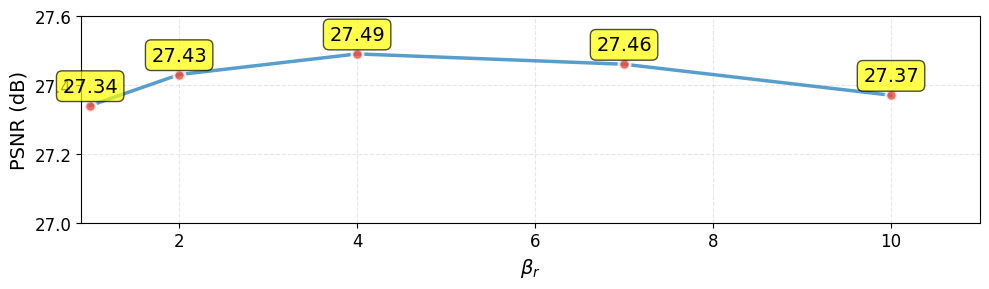

In [19]:
beta_r_curves = np.array(
    [
        # [0, 26.87],
        [1, 27.34],
        [2, 27.43],
        [4, 27.49],
        [7, 27.46],
        [10, 27.37],
        # [20, 27.11]
    ]
)

import matplotlib.pyplot as plt

# 创建一个更大的图形
plt.figure(figsize=(10, 3))

# 绘制曲线，添加样式
plt.plot(beta_r_curves[:,0], beta_r_curves[:,1], 
         'o-', linewidth=2.5, markersize=8, 
         color='#2E86C1', markerfacecolor='#E74C3C', 
         markeredgecolor='white', markeredgewidth=2, alpha=0.8)

# 添加标签（去掉标题）
plt.xlabel(r'$\beta_r$', fontsize=14)
plt.ylabel('PSNR (dB)', fontsize=14)

# 美化网格
plt.grid(True, alpha=0.3, linestyle='--')

# 设置坐标轴范围
plt.xlim(0.9, 11)
plt.ylim(27.0, 27.6)

# 添加数据点标签（增大字号）
for i, (x, y) in enumerate(beta_r_curves):
    plt.annotate(f'{y:.2f}', (x, y), textcoords="offset points", 
                xytext=(0,10), ha='center', fontsize=14, 
                bbox=dict(boxstyle="round,pad=0.3", facecolor='yellow', alpha=0.7))

# 美化坐标轴
plt.tick_params(axis='both', which='major', labelsize=12)

# 调整布局
plt.tight_layout()

# 显示图形
plt.show()

In [ ]:
depth_curves = np.array(
    [
        [0, 27.43],
        [1, 27.34],
        [2, 27.43],
        [4, 27.49],
        [7, 27.46],
        [10, 27.37],
        # [20, 27.11]
    ]
)

import matplotlib.pyplot as plt

# 创建一个更大的图形
plt.figure(figsize=(10, 3))

# 绘制曲线，添加样式
plt.plot(beta_r_curves[:,0], beta_r_curves[:,1], 
         'o-', linewidth=2.5, markersize=8, 
         color='#2E86C1', markerfacecolor='#E74C3C', 
         markeredgecolor='white', markeredgewidth=2, alpha=0.8)

# 添加标签（去掉标题）
plt.xlabel(r'$\beta_r$', fontsize=14)
plt.ylabel('PSNR (dB)', fontsize=14)

# 美化网格
plt.grid(True, alpha=0.3, linestyle='--')

# 设置坐标轴范围
plt.xlim(0.9, 11)
plt.ylim(27.0, 27.6)

# 添加数据点标签（增大字号）
for i, (x, y) in enumerate(beta_r_curves):
    plt.annotate(f'{y:.2f}', (x, y), textcoords="offset points", 
                xytext=(0,10), ha='center', fontsize=14, 
                bbox=dict(boxstyle="round,pad=0.3", facecolor='yellow', alpha=0.7))

# 美化坐标轴
plt.tick_params(axis='both', which='major', labelsize=12)

# 调整布局
plt.tight_layout()

# 显示图形
plt.show()

In [5]:
for key in reb_dict:
    print(key, reb_dict[key])

rebuttal_depth_prior_1_zoedepth /n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/test_ground/rebuttal_depth_prior_1_zoedepth/TPGS/results_rebuttal_depth_prior_1_zoedepth
rebuttal_depth_noise_1_5 /n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/test_ground/rebuttal_depth_noise_1_5/TPGS/results_rebuttal_depth_noise_1_5
rebuttal_depth_prior_1_depthpro /n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/test_ground/rebuttal_depth_prior_1_depthpro/TPGS/results_rebuttal_depth_prior_1_depthpro
rebuttal_depth_prior_1_moge /n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/test_ground/rebuttal_depth_prior_1_moge/TPGS/results_rebuttal_depth_prior_1_moge
rebuttal_depth_noise_1_15 /n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/test_ground/rebuttal_depth_noise_1_15/TPGS/results_rebuttal_depth_noise_1_15
rebuttal_beta_r_1_10 /n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfi

In [ ]:

from PIL import Image
dilated_mask = Image.open("/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/TPGS/data/nvidia_processed/foreground_masks_dilate/Balloon2/00000.png")
mask = Image.open("/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/TPGS/data/nvidia_processed/foreground_masks/Balloon2/00000.png")

image = Image.open("/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/TPGS/data/nvidia_processed/images/Balloon2/00000.jpg")

overlay_color = [231 / 255, 138 / 255, 195 / 255, 0.6]
def overlay_mask(image, mask, overlay_color):
    image = np.array(image) / 255.0
    mask = np.array(mask) / 255.0
    color = np.array(overlay_color[:3]).reshape(1, 1, 3)
    output = (1 - mask) * image + mask * (overlay_color[3] * color + (1 - overlay_color[3]) * image)
    mask = 

In [3]:
print("NVIDIA Results:")
collect_and_show_results(nvidia_result_dirs, nvidia_scenes)
print("iPhone Results:")
collect_and_show_results(iphone_result_dirs, iphone_scenes, "mpsnr", "mssim", "mlpips")

NVIDIA Results:
                                                Balloon1             Balloon2              Jumping                Truck              Skating             Umbrella           Playground                  avg
w_flow_sigmoid_lifespan              23.67/0.8165/0.0889  27.55/0.8840/0.0418  25.28/0.8563/0.0701  27.75/0.8796/0.0819  33.62/0.9531/0.0383  25.57/0.8053/0.0675  23.75/0.8830/0.0607  26.74/0.8683/0.0642
freetimegs                           23.79/0.8217/0.0783  27.80/0.8907/0.0397  25.37/0.8598/0.0661  28.46/0.8894/0.0645  34.15/0.9607/0.0265  25.88/0.8130/0.0610  24.33/0.8965/0.0493  27.11/0.8760/0.0550
freetimegs_no_limit                  23.80/0.8218/0.0789  27.84/0.8904/0.0413  25.31/0.8587/0.0682  28.55/0.8915/0.0613  33.89/0.9602/0.0254  25.91/0.8125/0.0610  24.37/0.8968/0.0492  27.10/0.8760/0.0550
w_flow                               23.68/0.8147/0.0947  27.47/0.8830/0.0439  24.79/0.8502/0.0822  27.49/0.8755/0.0880  33.34/0.9549/0.0313  25.17/0.7882/0.0934  23.27

In [7]:
import json
import os
import numpy as np
import pandas as pd

iphone_last = "/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/test_ground/iphone_longer_no_transient_new_new_new_2/TPGS/results_iphone_longer_no_transient_new_new_new_2"
nvidia_last = "/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/test_ground/nvidia_wo_transient/TPGS/results_nvidia_wo_transient"

nvidia_stats = {}
iphone_stats = {}

for scene in iphone_scenes:
    stats_path = os.path.join(iphone_last, scene, "stats", "train_step99999.json")
    with open(stats_path, "r") as f:
        data = json.load(f)
    iphone_stats[scene] = {
        "num_static_GS": data["num_static_GS"],
        # "num_transient_GS": data["num_transient_GS"],
        "num_dynamic_GS": data["num_dynamic_GS"],
        "num_total_GS": data["num_static_GS"] + data["num_transient_GS"] + data["num_dynamic_GS"],
        "train_time": data["ellipse_time"] / 3600.0,
        "max_mem": data["mem"]
    }
for scene in nvidia_scenes:
    stats_path = os.path.join(nvidia_last, scene, "stats", "train_step29999.json")
    with open(stats_path, "r") as f:
        data = json.load(f)
    nvidia_stats[scene] = {
        "num_static_GS": data["num_static_GS"],
        # "num_transient_GS": data["num_transient_GS"],
        "num_dynamic_GS": data["num_dynamic_GS"],
        "num_total_GS": data["num_static_GS"] + data["num_transient_GS"] + data["num_dynamic_GS"],
        "train_time": data["ellipse_time"] / 3600.0,
        "max_mem": data["mem"]
    }
iphone_stats["avg"] = {
    "num_static_GS": np.mean([iphone_stats[scene]["num_static_GS"] for scene in iphone_scenes]),
    # "num_transient_GS": np.mean([iphone_stats[scene]["num_transient_GS"] for scene in iphone_scenes]),
    "num_dynamic_GS": np.mean([iphone_stats[scene]["num_dynamic_GS"] for scene in iphone_scenes]),
    "num_total_GS": np.mean([iphone_stats[scene]["num_total_GS"] for scene in iphone_scenes]),
    "train_time": np.mean([iphone_stats[scene]["train_time"] for scene in iphone_scenes]),
    "max_mem": np.mean([iphone_stats[scene]["max_mem"] for scene in iphone_scenes])
}
nvidia_stats["avg"] = {
    "num_static_GS": np.mean([nvidia_stats[scene]["num_static_GS"] for scene in nvidia_scenes]),
    # "num_transient_GS": np.mean([nvidia_stats[scene]["num_transient_GS"] for scene in nvidia_scenes]),
    "num_dynamic_GS": np.mean([nvidia_stats[scene]["num_dynamic_GS"] for scene in nvidia_scenes]),
    "num_total_GS": np.mean([nvidia_stats[scene]["num_total_GS"] for scene in nvidia_scenes]),
    "train_time": np.mean([nvidia_stats[scene]["train_time"] for scene in nvidia_scenes]),
    "max_mem": np.mean([nvidia_stats[scene]["max_mem"] for scene in nvidia_scenes])
}   
df_iphone = pd.DataFrame(iphone_stats).T
df_nvidia = pd.DataFrame(nvidia_stats).T
print(df_iphone.to_string())
print(df_nvidia.to_string())

                num_static_GS  num_dynamic_GS   num_total_GS  train_time   max_mem
apple           288066.000000    23998.000000  312064.000000    1.686105  1.679927
block           136123.000000   110445.000000  246568.000000    1.885802  6.631079
paper-windmill  387559.000000    24845.000000  412404.000000    1.646570  0.655134
space-out       135605.000000    47986.000000  183591.000000    1.796757  1.899832
spin            283770.000000    31010.000000  314780.000000    1.796086  2.085503
teddy           101689.000000   197523.000000  299212.000000    2.304745  9.120628
wheel           216963.000000    86172.000000  303135.000000    1.537983  3.732192
avg             221396.428571    74568.428571  295964.857143    1.807721  3.686328
            num_static_GS  num_dynamic_GS   num_total_GS  train_time   max_mem
Balloon1    259834.000000    66593.000000  326427.000000    0.294072  3.015101
Balloon2    290789.000000    24959.000000  315748.000000    0.286809  0.712281
Jumping     2404